In [ ]:
import os
import zarr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path ='/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002'

MT_path = os.path.join(path, 'MTs.zarr')
MTR_path = os.path.join(path, 'MTs_red.zarr')
beads_path = os.path.join(path, 'beads.zarr')
track_path = os.path.join(path, 'beads_tracks.csv')

MT = zarr.open_array(MT_path, mode = 'r')[:]
MTR = zarr.open_array(MTR_path, mode = 'r')[:]
beads = zarr.open_array(beads_path, mode = 'r')[:]

plt.style.use('../libs/my_style.mplstyle')

beads_last_frame = beads.shape[0]

fig, ax = plt.subplots(figsize = (4,3))

ax.hist(beads[0:beads_last_frame:100].reshape(-1), bins = range(256))
ax.set(yscale='log')

KeyboardInterrupt: 

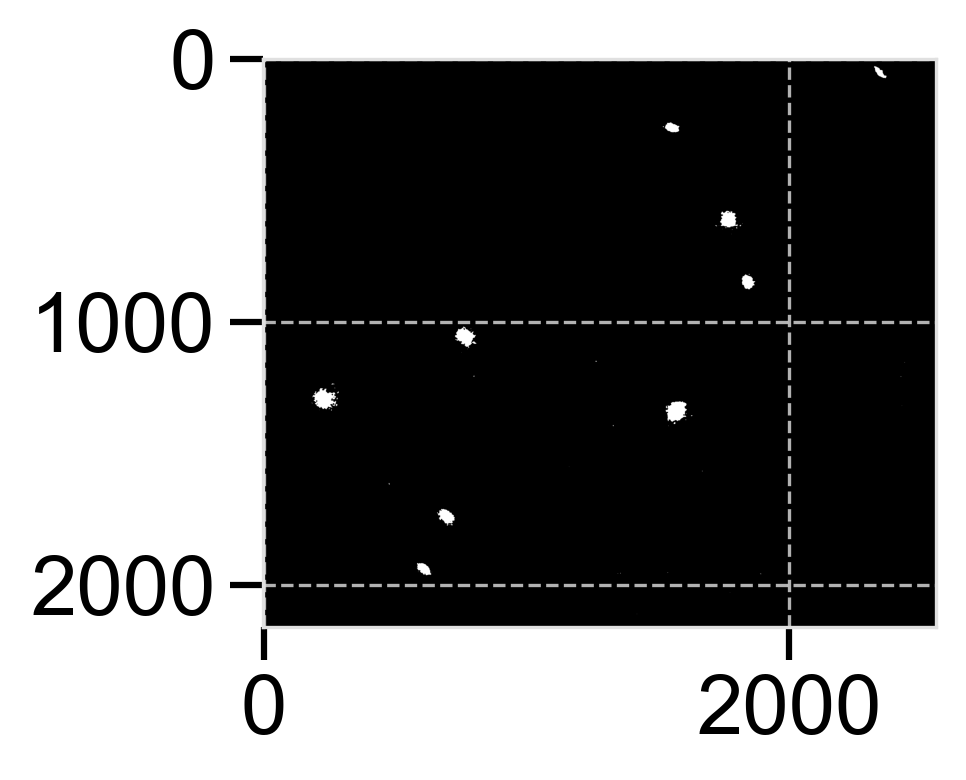

In [2]:
threshold = 200

binary_img = beads[0] > threshold
fig, ax = plt.subplots(figsize = (4,3))

ax.imshow(binary_img, cmap = 'gray')

In [3]:
beads_bin = beads[:] > threshold

# トラッキングデータ
track = pd.read_csv(track_path)

(np.float64(-0.5), np.float64(2559.5), np.float64(2159.5), np.float64(-0.5))

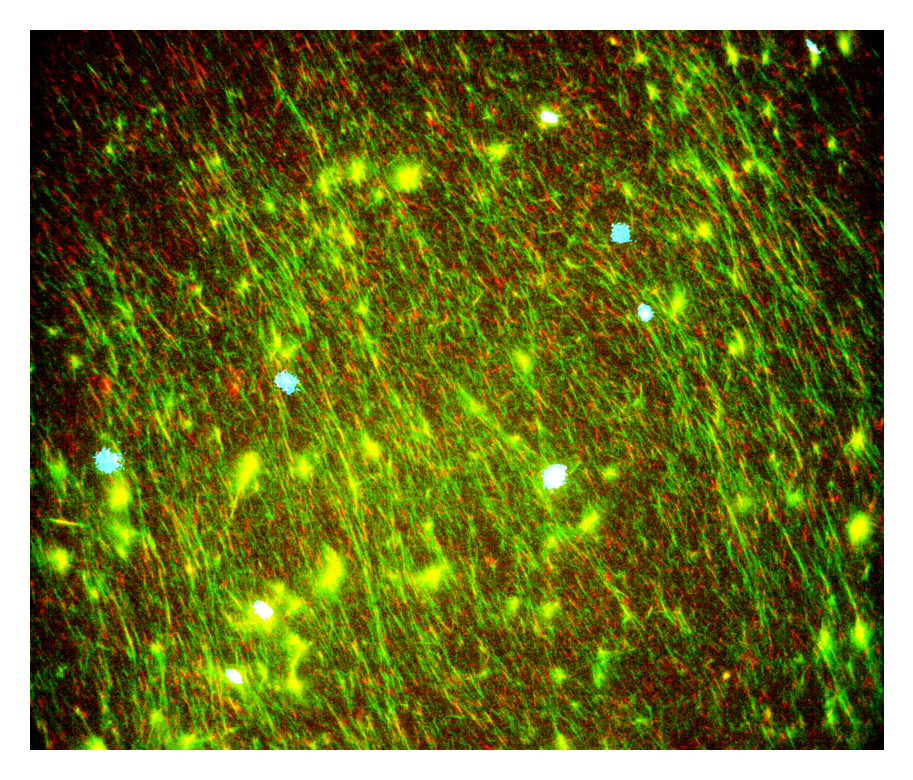

In [4]:
from PIL import ImageColor

def normalize_and_gamma(data, v_range, gamma):
    img = data.astype(np.float32)
    # 正規化とクリップ
    img = np.clip((img - v_range[0]) / (v_range[1] - v_range[0] + 1e-6), 0, 1)
    # ガンマ補正
    return np.power(img, gamma)

# 各チャンネルの表示輝度範囲 (vmin, vmax)
# 8bitデータの場合は 0〜255 の間で調整してください
V_RANGE_CH1 = (50, 255) 
V_RANGE_CH2 = (100, 255)
GAMMA = 1.2 # ガンマ補正値



# 色の設定 (RGB 0.0-1.0)
COLOR_CH1 = np.array(ImageColor.getcolor("#00FF00", "RGB"))/255
COLOR_CH2 = np.array(ImageColor.getcolor("#FF0000", "RGB"))/255
COLOR_MASK = np.array(ImageColor.getcolor("#1E90FF", "RGB"))/255

# 1. 通常チャンネルの読み込みと処理
img1 = normalize_and_gamma(MT[0], V_RANGE_CH1, GAMMA)
img2 = normalize_and_gamma(MTR[0], V_RANGE_CH2, GAMMA)

# 2. ベースとなるRGB画像の合成 (加算合成)
rgb_base = np.clip(
        np.atleast_3d(img1) * COLOR_CH1 +
        np.atleast_3d(img2) * COLOR_CH2 +
        np.atleast_3d(beads_bin[0]) * COLOR_MASK,
        0, 1
    )


fig, ax = plt.subplots(figsize = (4,3))
ax.imshow(rgb_base)

ax.axis('off')

In [5]:
import pandas as pd

def load_trackpy_csv(csv_path):
    df = pd.read_csv(csv_path)
    # 粒子IDをキーにして、各フレームの座標をリスト化
    trajectories = {}
    for pid, group in df.groupby('particle'):
        # 後の描画のために、フレーム番号でソートしておく
        group = group.sort_values('frame')
        trajectories[pid] = {
            'frames': group['frame'].values,
            'x': group['x'].values,
            'y': group['y'].values
        }
    return trajectories

# 使用例
trajectories = load_trackpy_csv(track_path)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import matplotlib.patheffects as pe # 縁取り用に追加
from tqdm.notebook import tqdm

# --- 設定 ---
OUTPUT_VIDEO = os.path.join(path, 'track_animation_fixed_with_time.mp4')
FPS = 25
DT = 4         # 1フレームあたりの実際の時間（秒）。実験条件に合わせて変更してください。
TRAJ_CMAP = plt.get_cmap('plasma') 
LINE_WIDTH = 20.0       
MARKER_SIZE = 20        
scale = 0.11           
DPI = 100
FONT_SIZE = 72              

# --- 画像データの形状取得 ---
# MT.shape = (Frames, Height, Width) と仮定
T_frames, H_size, W_size = MT.shape 
print(f"Video Size: {W_size}x{H_size}, Frames: {T_frames}")

# --- 前処理 ---
particle_tracks = {}
groups = track.groupby("particle")
for p, group in groups:
    # [frame, x, y]
    sorted_data = group.sort_values("frame")[["frame", "x", "y"]].values
    particle_tracks[p] = sorted_data

# --- 図の初期化 ---
plt.switch_backend('Agg')

# Figureサイズをピクセル数に完全に合わせます
fig = plt.figure(figsize=(W_size / DPI, H_size / DPI), dpi=DPI)

# [left, bottom, width, height] = [0, 0, 1, 1] で全体を使用
ax = fig.add_axes([0, 0, 1, 1]) 
ax.set_axis_off()

# 画像の初期化
im = ax.imshow(np.zeros((H_size, W_size, 3)), aspect='equal', zorder=1)

# --- LineCollectionとPointsの初期化 ---
line_collections = {}
points = {}
norm = Normalize(vmin=0, vmax=T_frames) 

for p in particle_tracks.keys():
    lc = LineCollection([], cmap=TRAJ_CMAP, norm=norm, alpha=0.8, linewidths=LINE_WIDTH, zorder=10)
    line_collections[p] = lc
    ax.add_collection(lc)
    
    pt, = ax.plot([], [], 'x', color=(1.0, 0.3, 0, 1.0), alpha=1.0, 
                  markersize=MARKER_SIZE, markeredgewidth=1.5, zorder=11)
    points[p] = pt

# --- スケールバー ---
fontprops = fm.FontProperties(size=FONT_SIZE)
size_bar = AnchoredSizeBar(ax.transData,
                           size=50/scale,
                           label='50\u03bcm',
                           loc=4, # 右下
                           pad=0.5,
                           color='white',
                           frameon=False,
                           size_vertical=20,
                           fontproperties=fontprops)
size_bar.set_zorder(20) 
ax.add_artist(size_bar)

# --- 【追加】タイムスタンプ表示 ---
# 右上 (x=0.95, y=0.95) に配置
# transform=ax.transAxes を使うことで、画像サイズに依存せず相対位置で指定できます
time_fontprops = fm.FontProperties(size=FONT_SIZE, family='monospace') # 数字の揺れを防ぐため等幅フォント推奨
time_text = ax.text(0.95, 0.95, "0.00 s", 
                    color='white', 
                    transform=ax.transAxes, 
                    ha='right', va='top', # 右揃え・上揃え
                    fontproperties=time_fontprops,
                    zorder=30)

# 文字に黒い縁取りを追加（背景が白くなっても読めるようにするプロのテクニック）
time_text.set_path_effects([pe.withStroke(linewidth=3, foreground='black')])


# --- 更新関数 ---
def update_frame(t):
    artists = []
    
    # 1. 画像合成
    img1 = normalize_and_gamma(MT[t], V_RANGE_CH1, GAMMA) 
    img2 = normalize_and_gamma(MTR[t], V_RANGE_CH2, GAMMA)
    mask = beads_bin[t].astype(np.float32)

    if img1.shape == (W_size, H_size):
        img1 = img1.T
        img2 = img2.T
        mask = mask.T
    
    rgb_base = np.clip(
        np.atleast_3d(img1) * COLOR_CH1 +
        np.atleast_3d(img2) * COLOR_CH2 +
        np.atleast_3d(mask) * COLOR_MASK,
        0, 1
    )
    
    im.set_array(rgb_base)
    artists.append(im)
    
    # 2. タイムスタンプ更新 【追加】
    # 現在の時刻を計算
    current_time = t * DT
    time_text.set_text(f"{current_time:.2f} s")
    artists.append(time_text)

    # 3. 軌跡更新
    for p, data in particle_tracks.items():
        history_mask = data[:, 0] <= t
        history = data[history_mask]

        if len(history) == 0:
            continue

        current_x, current_y = history[-1, 1], history[-1, 2]
        points[p].set_data([current_x], [current_y])
        artists.append(points[p])
        
        if len(history) > 1:
            pts = history[:, 1:3].reshape(-1, 1, 2)
            segments = np.concatenate([pts[:-1], pts[1:]], axis=1)
            colors_vals = history[:-1, 0] 
            
            line_collections[p].set_segments(segments)
            line_collections[p].set_array(colors_vals)
            artists.append(line_collections[p])
        else:
             line_collections[p].set_segments([])

    return artists

# --- 書き出し実行 ---
print(f"Rendering {T_frames} frames to {OUTPUT_VIDEO}...")
ani = FuncAnimation(fig, update_frame, frames=T_frames, blit=False)
extra_args = ['-vcodec', 'libx264', '-crf', '18', '-preset', 'fast']
writer = FFMpegWriter(fps=FPS, bitrate=-1, extra_args=extra_args)

with tqdm(total=T_frames) as pbar:
    ani.save(OUTPUT_VIDEO, writer=writer, dpi=DPI, progress_callback=lambda i, n: pbar.update(1))

plt.close(fig)
print("Done.")

Video Size: 2560x2160, Frames: 1002
Rendering 1002 frames to /Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002/track_animation_fixed_with_time.mp4...


  0%|          | 0/1002 [00:00<?, ?it/s]

/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_44573/2913943698.py:153: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ani.save(OUTPUT_VIDEO, writer=writer, dpi=DPI, progress_callback=lambda i, n: pbar.update(1))


Done.


In [8]:
import matplotlib.pyplot as plt
import os

plt.style.use('../libs/my_style.mplstyle')

def color_bar(vertical=False, save = False):
    """
    カラーマップのカラーバーを表示する。

    Args:
        colormap (str or LinearSegmentedColormap): 使用するカラーマップ。
        vertical (bool, optional): 縦方向のカラーバーにするか。デフォルトは False。
    """
    gradient = np.linspace(0, 1000, 1001).reshape(1, -1)  # グラデーションを作成
    if vertical:
        gradient = np.transpose(gradient)  # 縦向きに変換
        fig, ax = plt.subplots(figsize=(1, 4))  # 縦長の図を作成
        ax.xaxis.set_visible(False)  # x軸を非表示に
        ax.yaxis.set_visible(False)  # y軸を非表示に
        ax.set_ylim(0, 1000)
    else:
        fig, ax = plt.subplots(figsize=(4, 1))
        ax.xaxis.set_visible(False)  # x軸を非表示に
        ax.yaxis.set_visible(False)  # y軸を非表示に
        ax.set_xlim(0, 1000)

    ax.imshow(gradient, aspect="auto", cmap='plasma')
    ax.set_frame_on(False)  # グラフ枠を削除（任意）
    if save == True:
        fig.savefig(r"/Users/sasakinozomu/code/MTCargoSim/analysis/graph/figure/color_bar_plasma.png", bbox_inches='tight')
        fig.savefig(r"/Users/sasakinozomu/code/MTCargoSim/analysis/graph/figure/color_bar_plasma.pdf", bbox_inches='tight')
    plt.show()

color_bar(vertical=True, save=True)

/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_44573/2833058211.py:32: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [ ]:
# 赤だけの動画作成

import os
import zarr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path ='/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002'

MTR_path = os.path.join(path, 'MTs_red.zarr')
MTR = zarr.open_array(MTR_path, mode = 'r')[:]


plt.style.use('../libs/my_style.mplstyle')

from PIL import ImageColor

def normalize_and_gamma(data, v_range, gamma):
    img = data.astype(np.float32)
    # 正規化とクリップ
    img = np.clip((img - v_range[0]) / (v_range[1] - v_range[0] + 1e-6), 0, 1)
    # ガンマ補正
    return np.power(img, gamma)

# 各チャンネルの表示輝度範囲 (vmin, vmax)
# 8bitデータの場合は 0〜255 の間で調整してください
V_RANGE_CH1 = (50, 255) 
V_RANGE_CH2 = (100, 255)
GAMMA = 1.2 # ガンマ補正値



# 色の設定 (RGB 0.0-1.0)
COLOR_CH1 = np.array(ImageColor.getcolor("#00FF00", "RGB"))/255
COLOR_CH2 = np.array(ImageColor.getcolor("#FF0000", "RGB"))/255
COLOR_MASK = np.array(ImageColor.getcolor("#1E90FF", "RGB"))/255

# 1. 通常チャンネルの読み込みと処理
img2 = normalize_and_gamma(MTR[0], V_RANGE_CH2, GAMMA)

# 2. ベースとなるRGB画像の合成 (加算合成)
rgb_base = np.clip(
        np.atleast_3d(img2) * COLOR_CH2,
        0, 1
    )


fig, ax = plt.subplots(figsize = (4,3))
ax.imshow(rgb_base)

ax.axis('off')

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import matplotlib.patheffects as pe # 縁取り用に追加
from tqdm.notebook import tqdm

# --- 設定 ---
OUTPUT_VIDEO = os.path.join(path, 'MTsRed.mp4')
FPS = 25
DT = 4         # 1フレームあたりの実際の時間（秒）。実験条件に合わせて変更してください。
TRAJ_CMAP = plt.get_cmap('plasma') 
LINE_WIDTH = 20.0       
MARKER_SIZE = 20        
scale = 0.11           
DPI = 100
FONT_SIZE = 72              

# --- 画像データの形状取得 ---
# MT.shape = (Frames, Height, Width) と仮定
T_frames, H_size, W_size = MTR.shape 
print(f"Video Size: {W_size}x{H_size}, Frames: {T_frames}")

# --- 前処理 ---

# --- 図の初期化 ---
plt.switch_backend('Agg')

# Figureサイズをピクセル数に完全に合わせます
fig = plt.figure(figsize=(W_size / DPI, H_size / DPI), dpi=DPI)

# [left, bottom, width, height] = [0, 0, 1, 1] で全体を使用
ax = fig.add_axes([0, 0, 1, 1]) 
ax.set_axis_off()

# 画像の初期化
im = ax.imshow(np.zeros((H_size, W_size, 3)), aspect='equal', zorder=1)

# --- スケールバー ---
fontprops = fm.FontProperties(size=FONT_SIZE)
size_bar = AnchoredSizeBar(ax.transData,
                           size=50/scale,
                           label='50\u03bcm',
                           loc=4, # 右下
                           pad=0.5,
                           color='white',
                           frameon=False,
                           size_vertical=20,
                           fontproperties=fontprops)
size_bar.set_zorder(20) 
ax.add_artist(size_bar)

# --- 【追加】タイムスタンプ表示 ---
# 右上 (x=0.95, y=0.95) に配置
# transform=ax.transAxes を使うことで、画像サイズに依存せず相対位置で指定できます
time_fontprops = fm.FontProperties(size=FONT_SIZE, family='monospace') # 数字の揺れを防ぐため等幅フォント推奨
time_text = ax.text(0.95, 0.95, "0.00 s", 
                    color='white', 
                    transform=ax.transAxes, 
                    ha='right', va='top', # 右揃え・上揃え
                    fontproperties=time_fontprops,
                    zorder=30)

# 文字に黒い縁取りを追加（背景が白くなっても読めるようにするプロのテクニック）
time_text.set_path_effects([pe.withStroke(linewidth=3, foreground='black')])


# --- 更新関数 ---
def update_frame(t):
    artists = []
    
    # 1. 画像合成
    img2 = normalize_and_gamma(MTR[t], V_RANGE_CH2, GAMMA)

    if img2.shape == (W_size, H_size):
        img2 = img2.T
    
    rgb_base = np.clip(
        np.atleast_3d(img2) * COLOR_CH2,
        0, 1
    )
    
    im.set_array(rgb_base)
    artists.append(im)
    
    # 2. タイムスタンプ更新 【追加】
    # 現在の時刻を計算
    current_time = t * DT
    time_text.set_text(f"{current_time:.2f} s")
    artists.append(time_text)

    return artists

# --- 書き出し実行 ---
print(f"Rendering {T_frames} frames to {OUTPUT_VIDEO}...")
ani = FuncAnimation(fig, update_frame, frames=T_frames, blit=False)
extra_args = ['-vcodec', 'libx264', '-crf', '18', '-preset', 'fast']
writer = FFMpegWriter(fps=FPS, bitrate=-1, extra_args=extra_args)

with tqdm(total=T_frames) as pbar:
    ani.save(OUTPUT_VIDEO, writer=writer, dpi=DPI, progress_callback=lambda i, n: pbar.update(1))

plt.close(fig)
print("Done.")

Video Size: 2560x2160, Frames: 1002
Rendering 1002 frames to /Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002/MTsRed.mp4...


  0%|          | 0/1002 [00:00<?, ?it/s]

/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_65550/395477419.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ani.save(OUTPUT_VIDEO, writer=writer, dpi=DPI, progress_callback=lambda i, n: pbar.update(1))


Done.


Video Size: 2560x2160, Frames: 1002
Rendering 1002 frames to /Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002/MT.mp4...


  0%|          | 0/1002 [00:00<?, ?it/s]

/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_67821/280387960.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  ani.save(OUTPUT_VIDEO, writer=writer, dpi=DPI, progress_callback=lambda i, n: pbar.update(1))


Done.


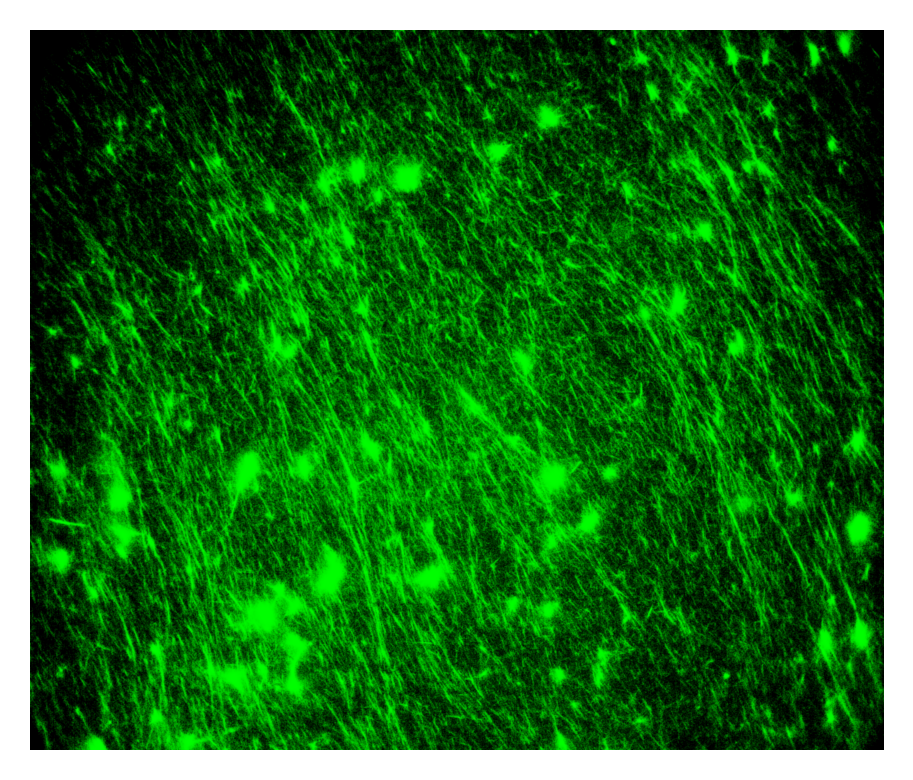

In [1]:
# 緑だけの動画作成
import os
import zarr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path ='/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002'

MT_path = os.path.join(path, 'MTs.zarr')
MT = zarr.open_array(MT_path, mode = 'r')[:]

plt.style.use('../libs/my_style.mplstyle')

from PIL import ImageColor

def normalize_and_gamma(data, v_range, gamma):
    img = data.astype(np.float32)
    # 正規化とクリップ
    img = np.clip((img - v_range[0]) / (v_range[1] - v_range[0] + 1e-6), 0, 1)
    # ガンマ補正
    return np.power(img, gamma)

# 各チャンネルの表示輝度範囲 (vmin, vmax)
# 8bitデータの場合は 0〜255 の間で調整してください
V_RANGE_CH1 = (50, 255) 
V_RANGE_CH2 = (100, 255)
GAMMA = 1.2 # ガンマ補正値



# 色の設定 (RGB 0.0-1.0)
COLOR_CH1 = np.array(ImageColor.getcolor("#00FF00", "RGB"))/255
COLOR_CH2 = np.array(ImageColor.getcolor("#FF0000", "RGB"))/255
COLOR_MASK = np.array(ImageColor.getcolor("#1E90FF", "RGB"))/255

# 1. 通常チャンネルの読み込みと処理
img1 = normalize_and_gamma(MT[0], V_RANGE_CH1, GAMMA)

# 2. ベースとなるRGB画像の合成 (加算合成)
rgb_base = np.clip(
        np.atleast_3d(img1) * COLOR_CH1,
        0, 1
    )


fig, ax = plt.subplots(figsize = (4,3))
ax.imshow(rgb_base)

ax.axis('off')

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import matplotlib.patheffects as pe # 縁取り用に追加
from tqdm.notebook import tqdm

# --- 設定 ---
OUTPUT_VIDEO = os.path.join(path, 'MT.mp4')
FPS = 25
DT = 4         # 1フレームあたりの実際の時間（秒）。実験条件に合わせて変更してください。
TRAJ_CMAP = plt.get_cmap('plasma') 
LINE_WIDTH = 20.0       
MARKER_SIZE = 20        
scale = 0.11           
DPI = 100
FONT_SIZE = 72              

# --- 画像データの形状取得 ---
# MT.shape = (Frames, Height, Width) と仮定
T_frames, H_size, W_size = MT.shape 
print(f"Video Size: {W_size}x{H_size}, Frames: {T_frames}")

# --- 図の初期化 ---
plt.switch_backend('Agg')

# Figureサイズをピクセル数に完全に合わせます
fig = plt.figure(figsize=(W_size / DPI, H_size / DPI), dpi=DPI)

# [left, bottom, width, height] = [0, 0, 1, 1] で全体を使用
ax = fig.add_axes([0, 0, 1, 1]) 
ax.set_axis_off()

# 画像の初期化
im = ax.imshow(np.zeros((H_size, W_size, 3)), aspect='equal', zorder=1)

# --- スケールバー ---
fontprops = fm.FontProperties(size=FONT_SIZE)
size_bar = AnchoredSizeBar(ax.transData,
                           size=50/scale,
                           label='50\u03bcm',
                           loc=4, # 右下
                           pad=0.5,
                           color='white',
                           frameon=False,
                           size_vertical=20,
                           fontproperties=fontprops)
size_bar.set_zorder(20) 
ax.add_artist(size_bar)

# --- 【追加】タイムスタンプ表示 ---
# 右上 (x=0.95, y=0.95) に配置
# transform=ax.transAxes を使うことで、画像サイズに依存せず相対位置で指定できます
time_fontprops = fm.FontProperties(size=FONT_SIZE, family='monospace') # 数字の揺れを防ぐため等幅フォント推奨
time_text = ax.text(0.95, 0.95, "0.00 s", 
                    color='white', 
                    transform=ax.transAxes, 
                    ha='right', va='top', # 右揃え・上揃え
                    fontproperties=time_fontprops,
                    zorder=30)

# 文字に黒い縁取りを追加（背景が白くなっても読めるようにするプロのテクニック）
time_text.set_path_effects([pe.withStroke(linewidth=3, foreground='black')])


# --- 更新関数 ---
def update_frame(t):
    artists = []
    
    # 1. 画像合成
    img1 = normalize_and_gamma(MT[t], V_RANGE_CH1, GAMMA) 

    if img1.shape == (W_size, H_size):
        img1 = img1.T
    
    rgb_base = np.clip(
        np.atleast_3d(img1) * COLOR_CH1,
        0, 1
    )
    
    im.set_array(rgb_base)
    artists.append(im)
    
    # 2. タイムスタンプ更新 【追加】
    # 現在の時刻を計算
    current_time = t * DT
    time_text.set_text(f"{current_time:.2f} s")
    artists.append(time_text)

    return artists

# --- 書き出し実行 ---
print(f"Rendering {T_frames} frames to {OUTPUT_VIDEO}...")
ani = FuncAnimation(fig, update_frame, frames=T_frames, blit=False)
extra_args = ['-vcodec', 'libx264', '-crf', '18', '-preset', 'fast']
writer = FFMpegWriter(fps=FPS, bitrate=-1, extra_args=extra_args)

with tqdm(total=T_frames) as pbar:
    ani.save(OUTPUT_VIDEO, writer=writer, dpi=DPI, progress_callback=lambda i, n: pbar.update(1))

plt.close(fig)
print("Done.")

In [16]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

cap_file = cv2.VideoCapture('/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002/MT.mp4')

In [20]:
cap_file.set(cv2.CAP_PROP_POS_FRAMES, 0)

True

In [21]:
ret, frame = cap_file.read()

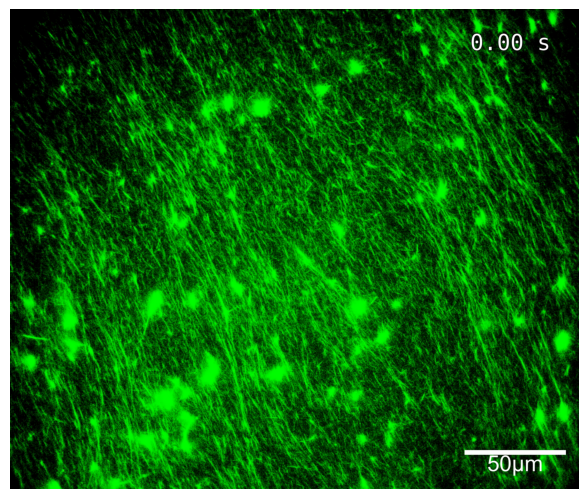

In [22]:
fig, ax = plt.subplots()
ax = fig.add_axes([0, 0, 1, 1]) 
ax.imshow(frame)

ax.axis('off')

fig.savefig('/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002/onlyMTG_trim.png')

In [10]:
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)